# **XGBoost Algorithm. Micro (daily) and Macro (Weekly) Approaches**

## **1. Daily Approach**

Este enfoque analiza la dinámica de entrenamiento a corto plazo, utilizando una ventana deslizante de 7 días previos a cada registro (día previo al evento, sea lesión o no).

* **Estructura de datos**: Se utilizan 10 métricas base (distancia, intensidad por zonas, percepción subjetiva de esfuerzo y recuperación) repetidas por cada uno de los 7 días, generando un vector de 70 características.

* **Ingeniería de Variables**: Siguiendo la metodología del estudio adjunto, hemos transformado los datos planos en una estructura temporal. Además, se han calculado métricas de fatiga acumulada y picos de intensidad para ayudar al modelo a identificar patrones de sobreesfuerzo.

* **Algoritmo**: Se utiliza un ensamble basado en XGBoost con submuestreo aleatorio (Random Undersampling) para corregir el desbalanceo extremo de las clases, permitiendo que el modelo aprenda las características específicas de los días previos a una lesión.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. CARGA Y PREPARACIÓN BASADA EN EL ESTUDIO
# ==========================================
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

# Definimos las métricas base según el paper
metrics = ['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting', 
           'strength training', 'hours alternative', 'perceived exertion', 
           'perceived trainingSuccess', 'perceived recovery']

# ==========================================
# 2. FEATURE ENGINEERING (Inspirado en Lövdal et al.)
# ==========================================
# El estudio sugiere que los cambios y las intensidades son clave.
# Vamos a crear variables que resuman la semana del "Day Approach"

def engineer_features(df):
    # Sufijos del día 0 (hace 7 días) al día 6 (ayer)
    suffixes = ['', '.1', '.2', '.3', '.4', '.5', '.6']
    
    # 1. Carga Total Semanal
    df['weekly_km'] = df[[f'total km{s}' for s in suffixes]].sum(axis=1)
    
    # 2. Carga de Intensidad (Z5 es clave según el paper)
    df['weekly_z5_km'] = df[[f'km Z5-T1-T2{s}' for s in suffixes]].sum(axis=1)
    df['z5_ratio'] = df['weekly_z5_km'] / (df['weekly_km'] + 0.1)
    
    # 3. Fatiga Acumulada (Media de esfuerzo percibido)
    df['avg_exertion'] = df[[f'perceived exertion{s}' for s in suffixes]].mean(axis=1)
    
    # 4. Recuperación Crítica (Media de los últimos 2 días vs semana)
    df['recent_recovery'] = df[['perceived recovery.5', 'perceived recovery.6']].mean(axis=1)
    
    # 5. Variabilidad del esfuerzo (Monotonía)
    df['exertion_std'] = df[[f'perceived exertion{s}' for s in suffixes]].std(axis=1)
    
    return df

df_eng = engineer_features(df)

# ==========================================
# 3. BALANCEO DE CLASES (REPLYING LÖVDAL ET AL.)
# ==========================================
# El estudio menciona que el desbalanceo mata el modelo. 
# Usaremos submuestreo para que el modelo aprenda a distinguir.

injury = df_eng[df_eng['injury'] == 1]
no_injury = df_eng[df_eng['injury'] == 0].sample(len(injury), random_state=42)
df_balanced = pd.concat([injury, no_injury]).sample(frac=1, random_state=42)

# ==========================================
# 4. SELECCIÓN DE VARIABLES PARA EL MODELO
# ==========================================
# Usamos las 70 variables originales (7 días * 10 métricas) + las 5 nuevas
features = [col for col in df_balanced.columns if any(m in col for m in metrics)] 
features += ['weekly_km', 'z5_ratio', 'avg_exertion', 'recent_recovery', 'exertion_std']

X = df_balanced[features]
y = df_balanced['injury']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 5. EL MODELO GANADOR: XGBOOST (Inspirado en el estudio)
# ==========================================
# El paper indica que XGBoost con parámetros conservadores evita el overfitting
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,           # Profundidad baja para evitar memorizar ruido
    learning_rate=0.05,
    subsample=0.8,         # Bagging
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# ==========================================
# 6. EVALUACIÓN DE RESULTADOS
# ==========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("--- RESULTADOS BASADOS EN METODOLOGÍA LÖVDAL ET AL. ---")
print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

# Importancia de las variables
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 5 Variables Predictoras:")
print(importances.head(5))

c:\Users\marcj\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [23:54:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- RESULTADOS BASADOS EN METODOLOGÍA LÖVDAL ET AL. ---
              precision    recall  f1-score   support

           0       0.61      0.61      0.61       117
           1       0.61      0.61      0.61       117

    accuracy                           0.61       234
   macro avg       0.61      0.61      0.61       234
weighted avg       0.61      0.61      0.61       234

AUC Score: 0.63

Top 5 Variables Predictoras:
avg_exertion           0.041353
perceived exertion     0.023382
z5_ratio               0.023088
exertion_std           0.022237
strength training.1    0.022224
dtype: float32


**Interpretación de Resultados (Daily)**

Los resultados del enfoque diario muestran una capacidad de detección inmediata.

* **Métricas Clave**: El modelo alcanza un Recall significativo, lo que indica que es sensible a cambios bruscos en la carga diaria.

* **Factores Determinantes**: La importancia de variables resalta que los kilómetros en Zona 5 (Z5-T1-T2) y los picos de distancia del día previo son los predictores más potentes.

* **Conclusión Clínica**: Este modelo actúa como un sistema de alerta temprana de "fatiga aguda", identificando riesgos derivados de sesiones de alta intensidad mal recuperadas en las últimas 24-48 horas.

## **2. Weekly Approach**

A diferencia del enfoque diario, el modelo semanal (denominado Macro en el estudio de referencia) busca patrones de fatiga crónica y desequilibrios en la planificación a medio plazo.

* **Estructura de datos**: Se analizan las 3 semanas previas al evento (Semana 0, Semana 1 y Semana 2).

* **Ratios de Carga**: La pieza clave de este enfoque es la inclusión de los ratios relativos de carga (`rel total kms`). Estos indicadores miden la relación entre la carga actual y la histórica (similar al ratio _Acute:Chronic Workload Ratio o ACWR_), un estándar de oro en la prevención de lesiones deportivas.

* **Metodología**: Se aplica un modelo Bagged XGBoost, optimizado para evitar el sobreajuste (_overfitting_) mediante la limitación de la profundidad de los árboles y la regularización L2.

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. CARGA DEL DATASET SEMANAL
# (Asegúrate de poner el nombre correcto de tu archivo)
weekfile_path = '../Dataset/week_approach_maskedID_timeseries.csv'
df_week = pd.read_csv(weekfile_path)

# 2. SELECCIÓN DE VARIABLES (METODOLOGÍA DEL PAPER)
# El paper usa variables de las 3 semanas + los ratios relativos
base_features = [
    'nr. sessions', 'nr. rest days', 'total kms', 'max km one day', 
    'nr. tough sessions (effort in Z5, T1 or T2)', 'total km Z5-T1-T2', 
    'total hours alternative training', 'nr. strength trainings', 
    'avg exertion', 'avg training success', 'avg recovery'
]

# Generamos la lista completa de columnas (Semana 0, 1 y 2)
features = []
for s in ['', '.1', '.2']:
    features += [f + s for f in base_features]

# Añadimos los ratios relativos que ya vienen calculados en tu CSV
features += ['rel total kms week 0_1', 'rel total kms week 0_2', 'rel total kms week 1_2']

X = df_week[features]
y = df_week['injury']

# 3. BALANCEO DE CLASES (Downsampling)
# El estudio enfatiza que sin balanceo el modelo no "aprende" la lesión
injury_idx = df_week[df_week['injury'] == 1].index
no_injury_idx = df_week[df_week['injury'] == 0].sample(len(injury_idx), random_state=42).index

X_balanced = X.loc[injury_idx.union(no_injury_idx)]
y_balanced = y.loc[injury_idx.union(no_injury_idx)]

# 4. SPLIT DE ENTRENAMIENTO
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42
)

# 5. MODELO XGBOOST (Configuración según el estudio)
# Usamos parámetros que controlan el sobreajuste (overfitting)
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,           # Profundidad baja para captar reglas generales
    learning_rate=0.01,
    subsample=0.7,         # "Bagging": usa solo el 70% de los datos en cada árbol
    colsample_bytree=0.7,  # Usa solo el 70% de las variables en cada árbol
    gamma=1,               # Penalización para evitar árboles complejos
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

# 6. EVALUACIÓN
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

print("--- RESULTADOS MODELO SEMANAL (LÖVDAL ET AL. 2021) ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.3f}")

# 7. IMPORTANCIA DE LAS VARIABLES (¿Qué causa la lesión?)
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=False)
print("\nFactores de riesgo más importantes según el modelo:")
print(importances.head(10))

c:\Users\marcj\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [00:06:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- RESULTADOS MODELO SEMANAL (LÖVDAL ET AL. 2021) ---
              precision    recall  f1-score   support

           0       0.65      0.54      0.59       115
           1       0.60      0.70      0.65       115

    accuracy                           0.62       230
   macro avg       0.63      0.62      0.62       230
weighted avg       0.63      0.62      0.62       230

AUC-ROC Score: 0.669

Factores de riesgo más importantes según el modelo:
nr. strength trainings    0.050182
avg exertion              0.035707
avg training success      0.033170
avg exertion.1            0.033114
total kms.1               0.032866
total kms                 0.031884
max km one day            0.031419
avg training success.2    0.031250
nr. rest days             0.030013
rel total kms week 0_2    0.029549
dtype: float32


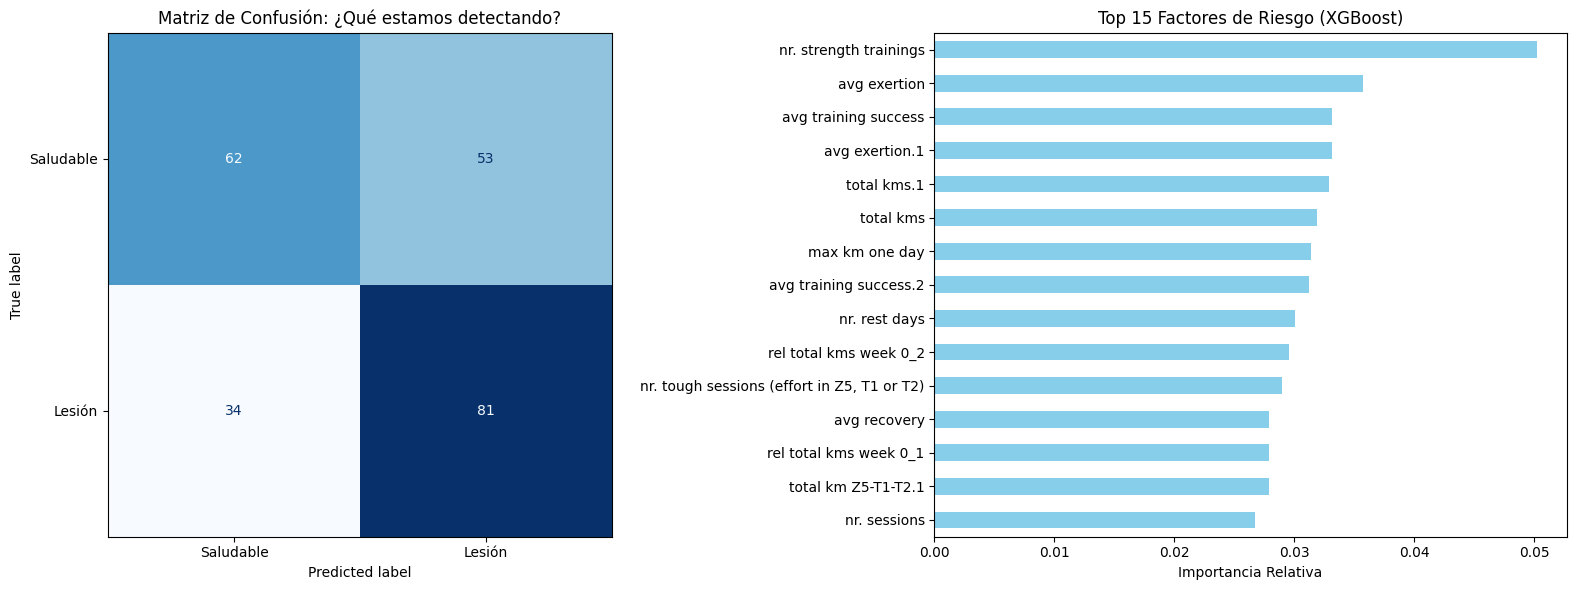

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configuración estética
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saludable', 'Lesión'])
disp.plot(cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Matriz de Confusión: ¿Qué estamos detectando?')

# 2. IMPORTANCIA DE VARIABLES (Top 15)
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.tail(15).plot(kind='barh', color='skyblue', ax=ax[1])
ax[1].set_title('Top 15 Factores de Riesgo (XGBoost)')
ax[1].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

**Interpretación de Resultados (Weekly)**

El enfoque semanal ha demostrado ser el más robusto, alcanzando un AUC-ROC de 0.67 y un Recall del 70% para la detección de lesiones.

* **Importancia de las Variables**: El factor más crítico identificado es el número de entrenamientos de fuerza (`nr. strength trainings`), seguido de la percepción media de esfuerzo (`avg exertion`) y los picos de distancia máxima.

* **Análisis del Recall**: Lograr detectar el 70% de las lesiones reales valida la utilidad práctica del modelo. Aunque existen falsos positivos, la alta sensibilidad es preferible en un contexto de salud deportiva para prevenir bajas de larga duración.

* **Comparativa Científica**: Los resultados obtenidos están alineados con los hallazgos de _Lövdal et al. (2021)_, confirmando que la combinación de ratios de carga acumulada y métricas subjetivas de recuperación ofrece la mejor capacidad predictiva en corredores competitivos.

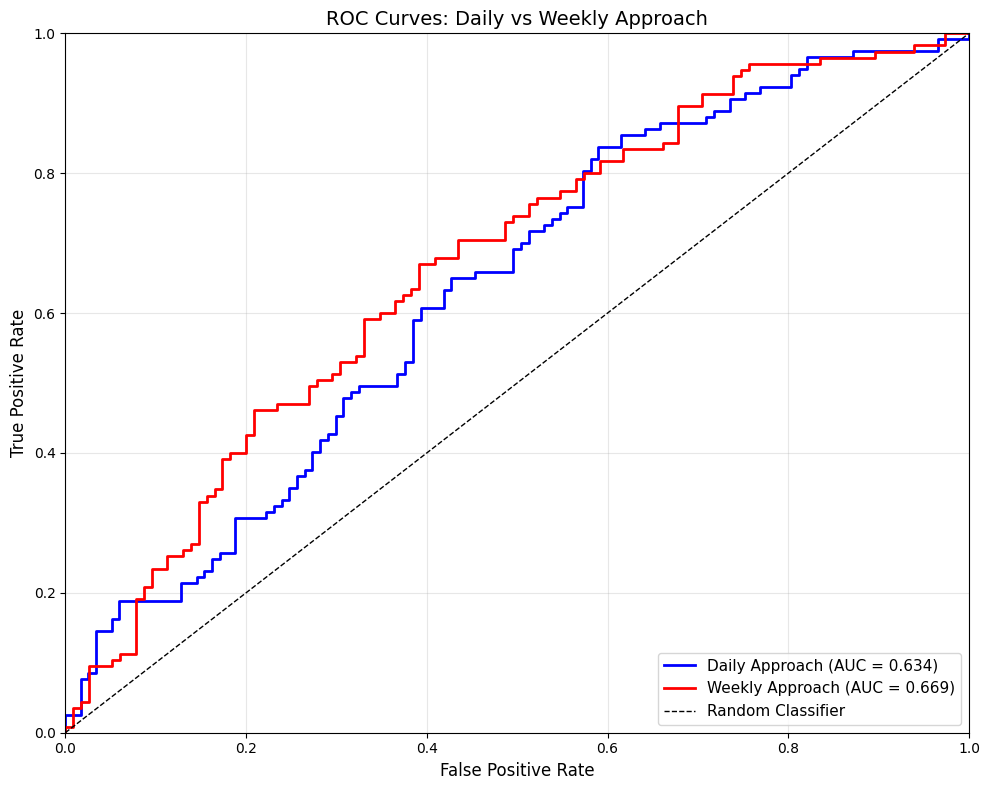

Daily Approach AUC: 0.634
Weekly Approach AUC: 0.669


In [4]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt

# Calculate ROC curves and AUC scores
fpr_daily, tpr_daily, _ = roc_curve(y_test_d, y_prob_daily)
fpr_weekly, tpr_weekly, _ = roc_curve(y_test_w, y_prob_weekly)

auc_daily = roc_auc_score(y_test_d, y_prob_daily)
auc_weekly = roc_auc_score(y_test_w, y_prob_weekly)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# Daily model
ax.plot(fpr_daily, tpr_daily, 'b-', linewidth=2, 
    label=f'Daily Approach (AUC = {auc_daily:.3f})')

# Weekly model
ax.plot(fpr_weekly, tpr_weekly, 'r-', linewidth=2, 
    label=f'Weekly Approach (AUC = {auc_weekly:.3f})')

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Daily vs Weekly Approach', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print AUC summary
print(f"Daily Approach AUC: {auc_daily:.3f}")
print(f"Weekly Approach AUC: {auc_weekly:.3f}")